## 1.1 安裝套件(若在colab訓練每次都需要執行)

In [ ]:
!pip install fastbook -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.3 MB/s eta 0:00:00



## 1.2 掛載Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.3 讀取套件

In [1]:
## 模型位置
from fastbook import *
from fastai.vision.widgets import *
from torchvision.transforms.functional import to_tensor

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [2]:
class Hook():
  def __init__(self, m):
      self.hook = m.register_forward_hook(self.hook_func)
  def hook_func(self, m, i, o): self.stored = o.detach().clone()
  def __enter__(self, *args): return self
  def __exit__(self, *args): self.hook.remove()

In [3]:
class HookBwd():
  def __init__(self, m):
      self.hook = m.register_backward_hook(self.hook_func)
  def hook_func(self, m, gi, go): self.stored = go[0].detach().clone()
  def __enter__(self, *args): return self
  def __exit__(self, *args): self.hook.remove()

## 2. Visualization with Grad-CAM

## 2.1 讀取先前訓練好的權重

In [20]:
myModel='models/Human_Face_Emotions/demo_stage-3.pkl'
learn = load_learner(myModel)

#顯示模型訓練時的類別名稱
class_names = learn.dls.vocab
print(class_names)

['Angry', 'Fear', 'Happy', 'Sad', 'Suprise']


## 2.2 讀取檔案並送入模型預測

In [21]:
## 執行預測 - method I
target_cls = class_names[0]

fnames_target_cls = get_image_files(f'datasets/Human_Face_Emotions/{target_cls}')

In [22]:
test_dl = learn.dls.test_dl(fnames_target_cls, with_label=True)
print(len(test_dl.get_idxs()))

10148


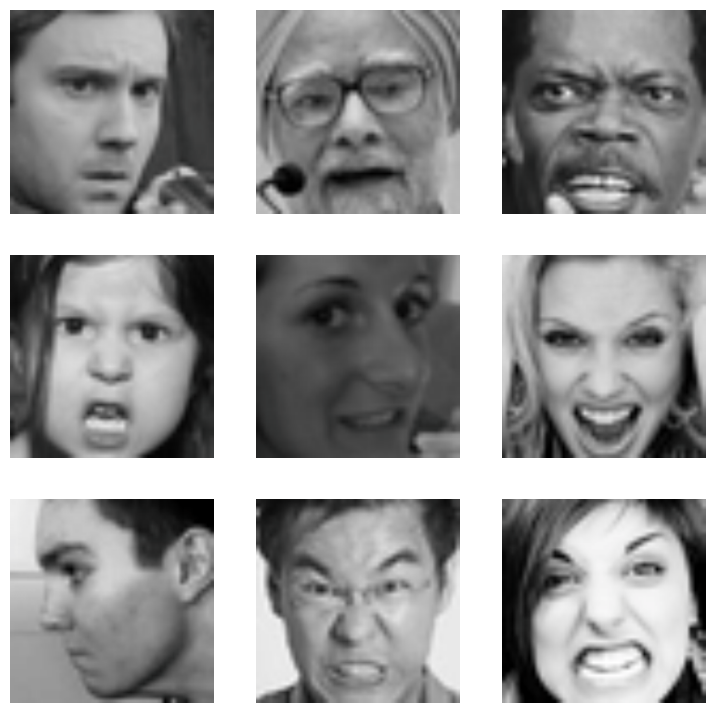

In [23]:
test_dl.show_batch()

## 2.3 讀取要繪製的影像

In [24]:
#修改idx來設定第幾張影像
idx = 0

fn = test_dl.items[0]
x_dec = PILImage.create(fn)

#Resize: 224  填充黑邊
rsz = Resize(224, method=ResizeMethod.Pad, pad_mode=PadMode.Zeros)
x_dec = rsz(x_dec)
x = to_tensor(x_dec)

#送入模型的input必須增加一個維度(batch, channel, w, h)
x.unsqueeze_(0)
print( x.shape,type(x) )

torch.Size([1, 3, 224, 224]) <class 'torch.Tensor'>


## 2.4 繪製最後一層的feature map的Grad-CAM

In [25]:
#如果想看特定類別的grad-cam 可以手動修改cls, 預設是根據模型預測的類別顯示
pred_class, cls, outputs = learn.predict(fnames_target_cls[idx])

with HookBwd(learn.model[0]) as hookg:
  with Hook(learn.model[0]) as hook:
      # output = learn.model.eval()(x.cuda())
      output = learn.model.eval()(x.cpu())
      act = hook.stored
  output[0,cls].backward()
  grad = hookg.stored

In [26]:
w = grad[0].mean(dim=[1,2], keepdim=True)
cam_map = (w * act[0]).sum(0)

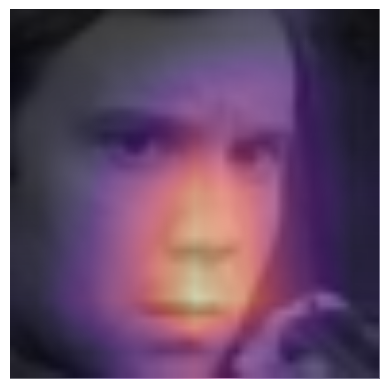

In [27]:
_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(cam_map.detach().cpu(), alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='magma');

## 3.1 以下是針對設定單張照片提供範例

torch.Size([1, 3, 224, 224]) <class 'torch.Tensor'>


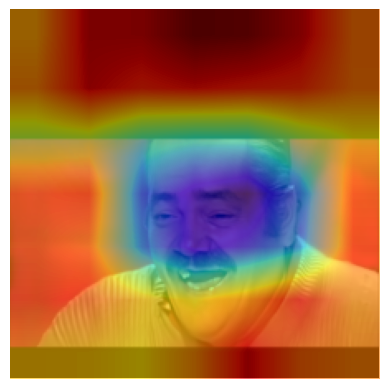

In [28]:
# 設定影像路徑
image_path = 'test_set/image.png'
x_dec = PILImage.create(image_path)

#Resize: 224  填充黑邊
rsz = Resize(224, method=ResizeMethod.Pad, pad_mode=PadMode.Zeros)
x_dec = rsz(x_dec)
x = to_tensor(x_dec)

#送入模型的input必須增加一個維度(batch, channel, w, h)
x.unsqueeze_(0)
print( x.shape,type(x) )

#如果想看特定類別的grad-cam 可以手動修改cls, 預設是根據模型預測的類別顯示
pred_class, cls, outputs = learn.predict(image_path)

with HookBwd(learn.model[0]) as hookg:
  with Hook(learn.model[0]) as hook:
      # output = learn.model.eval()(x.cuda())
      output = learn.model.eval()(x.cpu())
      act = hook.stored
  output[0,cls].backward()
  grad = hookg.stored

w = grad[0].mean(dim=[1,2], keepdim=True)
cam_map = (w * act[0]).sum(0)

_,ax = plt.subplots()
x_dec.show(ctx=ax)
ax.imshow(cam_map.detach().cpu(), alpha=0.6, extent=(0,224,224,0),
              interpolation='bilinear', cmap='jet');